# Edward Moswane Assignment 8: Supervised Learning Classification

**Introduction:**
I have selected the Breast Cancer Wisconsin (Diagnostic) dataset because it is a public dataset suitable for binary classification. The aim is to preprocess the dataset, explore signficant patterns, train classification models, compare their performance, and identify the best model for deployment and monitoring

# Dataset Selection and Preprocessing

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)

In [ ]:
# Loading the chosen dataset
data = load_breast_cancer()

# Creating a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Adding target variable
df['target'] = data.target

# show first few rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (569, 31)


In [ ]:
# Check information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# Checking missing values
print("\nMissing values:")
print(df.isnull().sum().sum())


Missing values:
0


In [ ]:
# Checking for duplicate rows
print("\nDuplicate records:", df.duplicated().sum())


Duplicate records: 0


In [ ]:
# Show stats summary
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
# Checking zero values in each column
zero_counts = (df == 0).sum()

print("Columns containing zero values:")
print(zero_counts[zero_counts > 0])

Columns containing zero values:
mean concavity           13
mean concave points      13
concavity error          13
concave points error     13
worst concavity          13
worst concave points     13
target                  212
dtype: int64


The dataset contained some zero values in a small number of features. I have double checked the values and made sure they are not automatically treated as missing values because zero can represent a valid measured feature value in this chosen dataset.

# Exploratory Data Analysis (EDA):


Distribution of Classes

target
1    357
0    212
Name: count, dtype: int64


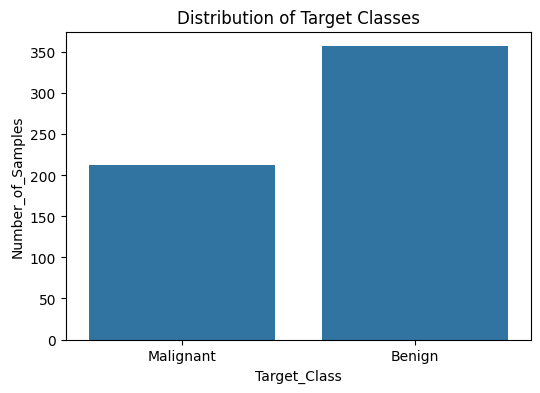

In [ ]:
# shoq the class distribution
print(df['target'].value_counts())

# Plot the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Classes')
plt.xlabel('Target_Class')
plt.ylabel('Number_of_Samples')
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.show()

Feature Distributions

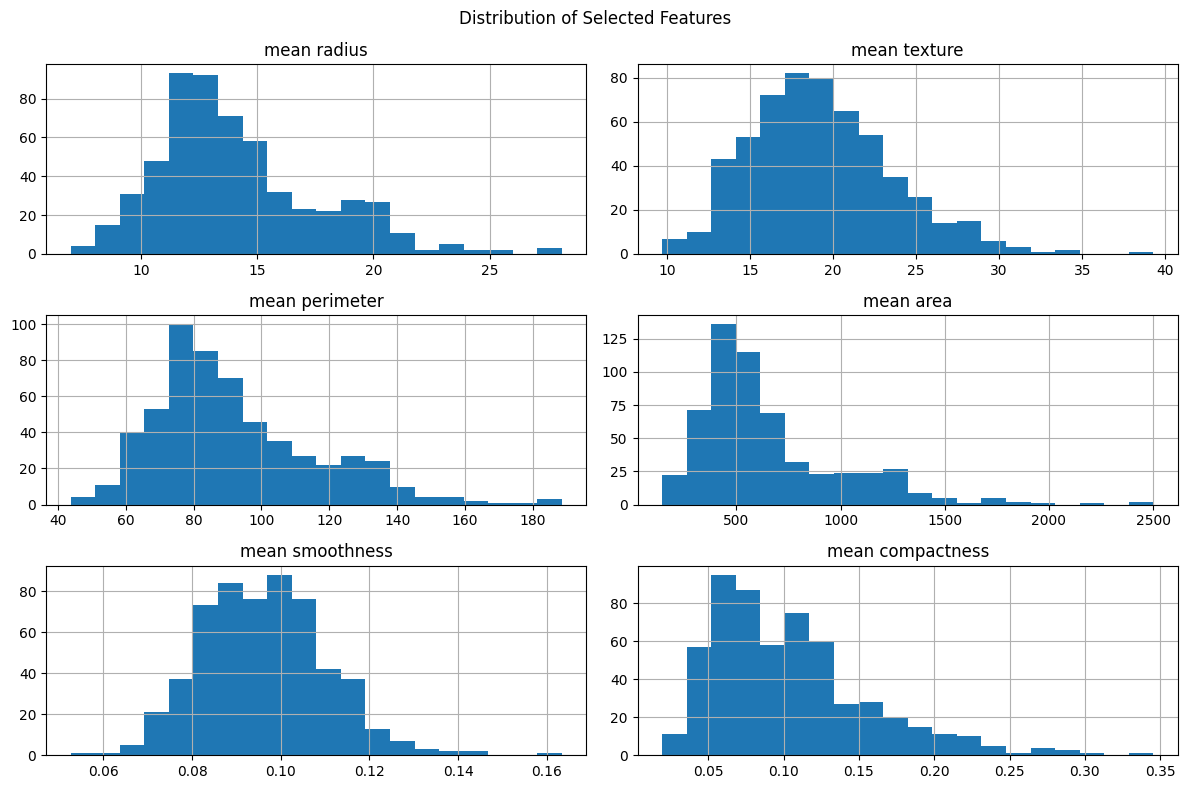

In [ ]:
# Visualize distributions of selected features
selected_features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness',
    'mean compactness']

df[selected_features].hist(figsize=(12, 8), bins=20)
plt.suptitle('Distribution of Selected Features')
plt.tight_layout()
plt.show()

In [ ]:
#saving the plot
plt.savefig("selected_features_distributions.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Correlation Heatmap

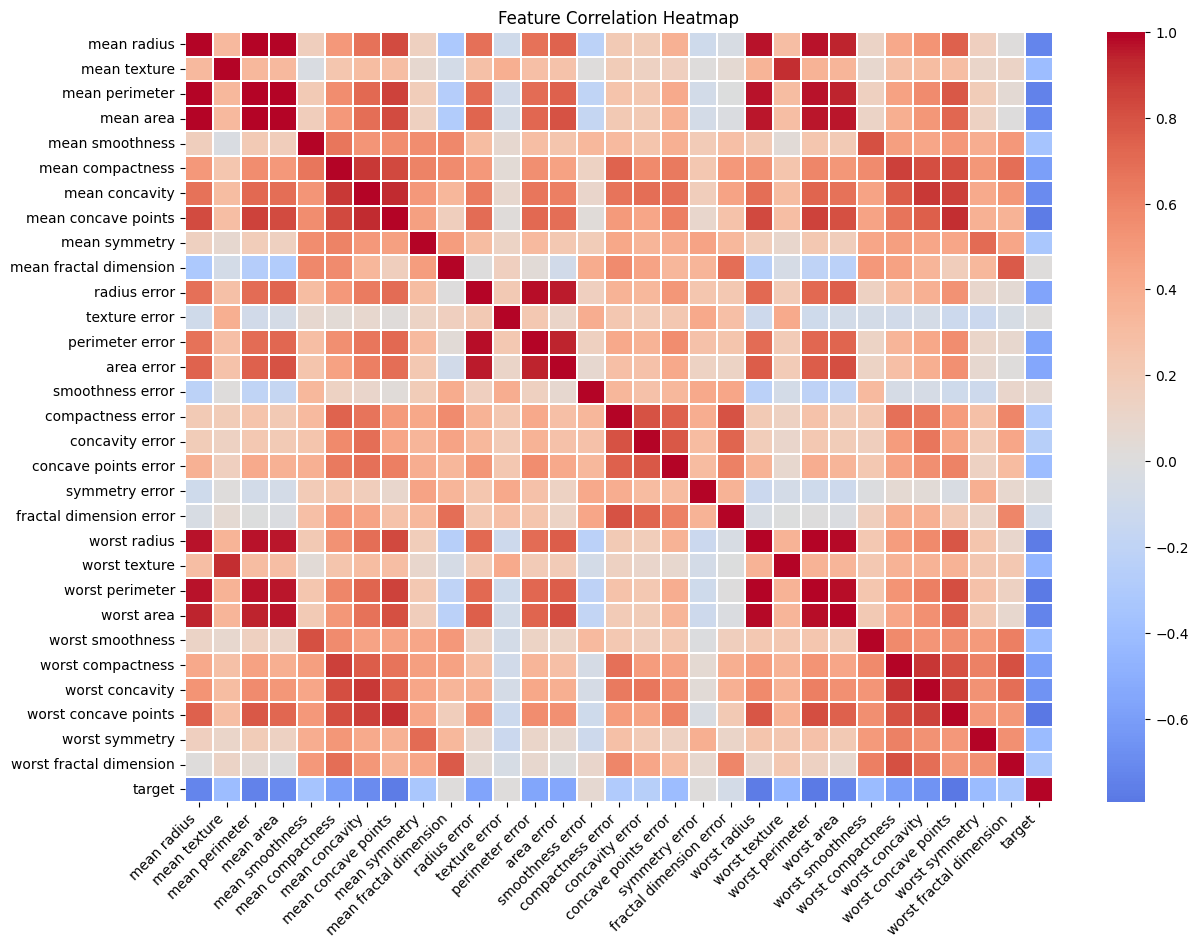

In [ ]:
# Correlation between features
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix,cmap='coolwarm',center=0,linewidths=0.2)
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
#Saving the heatmap
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [ ]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


# Model Implementation and Evaluation:

Train and Test Split dataset

In [ ]:
# Spliting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


Scaling the Dataset

In [ ]:
# Creating the scaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully completed!!.")
print("Testing data scaled successfully completed!!.")

Training data scaled successfully completed!!.
Testing data scaled successfully completed!!.


First Chosen Model K-Nearest Neighbors

In [ ]:
# Creating the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Training the model
knn.fit(X_train_scaled, y_train)

# Making predictions
y_pred_knn = knn.predict(X_test_scaled)

print("KNN model trained successfully!!!.")

KNN model trained successfully!!!.


Evaluate the models on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [ ]:
# Calculate KNN performance metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

# Probability predictions for ROC-AUC
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
knn_roc_auc = roc_auc_score(y_test, y_prob_knn)

print("The KNN Performance")
print("Accuracy:", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall:", round(knn_recall, 4))
print("F1-score:", round(knn_f1, 4))
print("ROC-AUC:", round(knn_roc_auc, 4))

The KNN Performance
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1-score: 0.9655
ROC-AUC: 0.9788


In [ ]:
print("_____________KNN Classification Report____________")
print(classification_report(y_test,y_pred_knn,target_names=['Malignant', 'Benign']))

_____________KNN Classification Report____________
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



KNN Confusion Matrix

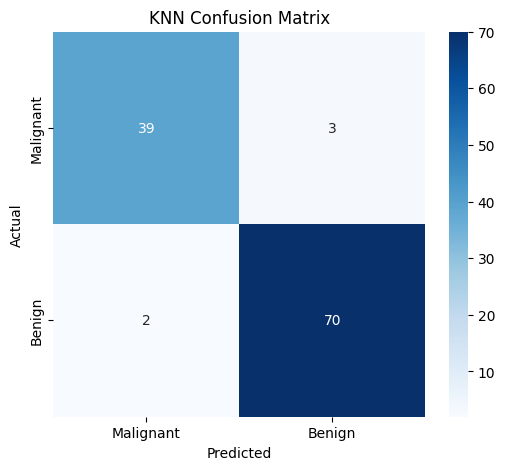

In [ ]:
# KNN confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign'])

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Second Model Logistic Regression

In [ ]:
# Creating Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Training the model
logistic_model.fit(X_train_scaled, y_train)

# Making predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model training successfully completed!!.")

Logistic Regression model training successfully completed!!.


Evaluate Logistic Regression Model  using appropriate metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [ ]:
# Calculate Logistic Regression metrics
log_accuracy = accuracy_score(y_test, y_pred_logistic)
log_precision = precision_score(y_test, y_pred_logistic)
log_recall = recall_score(y_test, y_pred_logistic)
log_f1 = f1_score(y_test, y_pred_logistic)

# Probability predictions for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
log_roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("_____Logistic Regression Performance______")
print("Accuracy:", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1-score:", round(log_f1, 4))
print("ROC-AUC:", round(log_roc_auc, 4))

_____Logistic Regression Performance______
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-score: 0.9861
ROC-AUC: 0.9954


In [ ]:
print("_______Logistic Regression Classification Report_______")
print(classification_report(y_test,y_pred_logistic,target_names=['Malignant', 'Benign']))

_______Logistic Regression Classification Report_______
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Logistic Regression Confusion Matrix

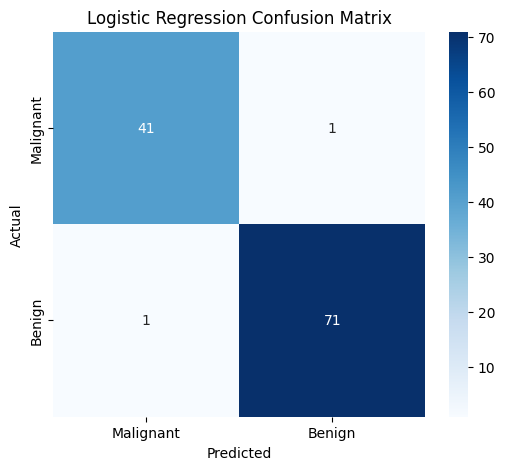

In [ ]:
# Logistic Regression confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logistic,annot=True,fmt='d',cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign'])

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Interpretation and Inference:

Compare model performance

In [ ]:
# Compare model performance
results = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression'],
    'Accuracy': [knn_accuracy, log_accuracy],
    'Precision': [knn_precision, log_precision],
    'Recall': [knn_recall, log_recall],
    'F1-Score': [knn_f1, log_f1],
    'ROC-AUC': [knn_roc_auc, log_roc_auc]})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.9561,0.9589,0.9722,0.9655,0.9788
1,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954


ROC Curves

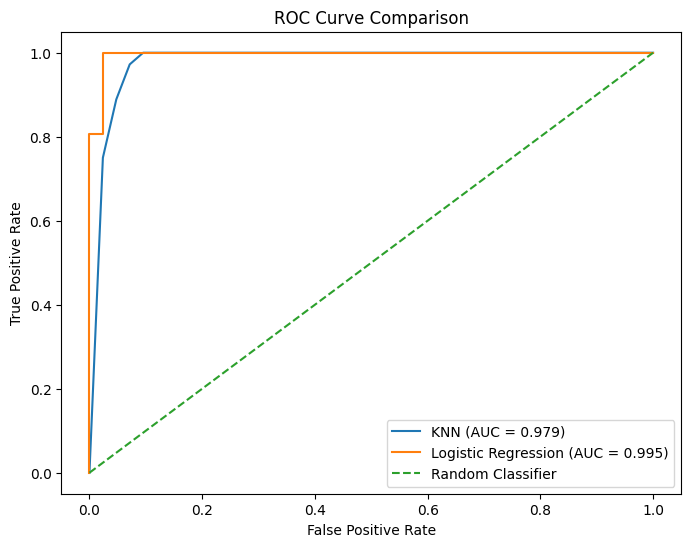

In [ ]:
# Calculating ROC curves
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn,tpr_knn,label=f'KNN (AUC = {knn_roc_auc:.3f})')
plt.plot(fpr_log,tpr_log,label=f'Logistic Regression (AUC = {log_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Hyperparameter Optimization (Grid Search)

In [ ]:
# Define K values to test
param_grid = {'n_neighbors': range(1, 21)}

# Creating GridSearchCV and perform grid search
grid_search = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("Best K:", grid_search.best_params_['n_neighbors'])
print("Cross-Validation Accuracy:",round(grid_search.best_score_, 4))

Best K: 8
Cross-Validation Accuracy: 0.9714


In [ ]:
# Create optimized KNN model
best_knn = grid_search.best_estimator_

# Predict on test data
y_pred_best_knn = best_knn.predict(X_test_scaled)

# Evaluate optimized KNN
best_knn_accuracy = accuracy_score(y_test, y_pred_best_knn)
best_knn_precision = precision_score(y_test, y_pred_best_knn)
best_knn_recall = recall_score(y_test, y_pred_best_knn)
best_knn_f1 = f1_score(y_test, y_pred_best_knn)

y_prob_best_knn = best_knn.predict_proba(X_test_scaled)[:, 1]
best_knn_roc_auc = roc_auc_score(y_test, y_prob_best_knn)

print("______Optimized KNN Performance_______")
print("Accuracy:", round(best_knn_accuracy, 4))
print("Precision:", round(best_knn_precision, 4))
print("Recall:", round(best_knn_recall, 4))
print("F1-score:", round(best_knn_f1, 4))
print("ROC-AUC:", round(best_knn_roc_auc, 4))

______Optimized KNN Performance_______
Accuracy: 0.9737
Precision: 0.9726
Recall: 0.9861
F1-score: 0.9793
ROC-AUC: 0.9909


Saving the Best Model

In [ ]:
# Choosing Logistic Regression as the best-performing model
best_model = logistic_model

# Save the best-performing model and scaler used during preproccessing
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Best model (Logistic Regression) and scaler saved successfully.")

Best model (Logistic Regression) and scaler saved successfully.


Loading the Model

In [ ]:
# Loading the saved best model and scaler
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Transform the test data
X_test_loaded = loaded_scaler.transform(X_test)

# Making predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test_loaded)

print("Loaded model predictions:")
print(loaded_predictions[:10])

Loaded model predictions:
[0 1 0 1 0 1 1 0 0 0]


In [ ]:
# Verifying loaded model produces the same predictions
print("Predictions match:",np.array_equal(y_pred_logistic, loaded_predictions))

Predictions match: True


# Deployment and Monitoring:


The best-performing Logistic Regression model could be deployed as a REST API using a framework such as FastAPI. The trained model would be saved and loaded by the application. When new patient data is received, the input would be validated and transformed using the same preprocessing steps used during training.

The processed data would then be passed to the Logistic Regression model in order to make a prediction. The prediction will be returned to healthcare system. This will be done with appropriate data security and privacy to protect patient information.

Potential issues include missing, incosistent or incorrect data, data drift, and system failures. Data should be validated, cleaned exlpored and properly scaled before making predictions. The model should be regularly monitored using accuracy, precision, recall, F1-score, and ROC-AUC. If performance start to decline or data changes significantly, the model should be reviewed and retrained as soon as possible to maintain good performance.

# Conclusion:
K-NN and Logistic Regression model were evaluated. Logistic Regression performed best, achieving 98.25% accuracy and 99.54% ROC-AUC. KNN was further optimized using Grid Search, which identified K = 8 as the best value. Although optimized KNN improved over the initial KNN model. Logistic Regression performed the best overall model. Therefore, Logistic Regression was selected as the final model for deployment

Colab LInk

https://colab.research.google.com/drive/1asDmJe1eC2jQnvRPmbgQeVG5Riw9Z0HQ?usp=sharing